# Práctica 2 – Detección de anomalías en datos de sensores

Análisis comparativo de detección de anomalías offline y streaming en datos de sensores industriales

- Cargamos el dataset `sensor.csv` de una bomba de agua.
- Preprocesamos ligeramente los datos.
- Aplicamos detección de anomalías en modo **offline**:
  - IQR por sensor.
  - K-Means (scikit-learn) + distancia al centroide.
- Aplicamos detección de anomalías en modo **online**:
  - Half-Space Trees (HST) con la librería `river`.
- Comparamos cuántas anomalías detecta cada método y cómo se relacionan con `machine_status`.\

## Imports y carga de datos

In [ ]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer

import matplotlib.pyplot as plt

from river import preprocessing, anomaly

# Mostrar más columnas si hace falta
pd.set_option("display.max_columns", 60)

# Cargar el CSV
df = pd.read_csv("sensor.csv")

df.head()

,Unnamed: 0,timestamp,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,sensor_08,sensor_09,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,sensor_22,sensor_23,sensor_24,sensor_25,sensor_26,sensor_27,sensor_28,sensor_29,sensor_30,sensor_31,sensor_32,sensor_33,sensor_34,sensor_35,sensor_36,sensor_37,sensor_38,sensor_39,sensor_40,sensor_41,sensor_42,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51,machine_status
0,0,2018-04-01 00:00:00,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,15.56713,15.05353,37.22740,47.52422,31.11716,1.681353,419.5747,NaN,461.8781,466.3284,2.565284,665.3993,398.9862,880.0001,498.8926,975.9409,627.6740,741.7151,848.0708,429.0377,785.1935,684.9443,594.4445,682.8125,680.4416,433.7037,171.9375,341.9039,195.0655,90.32386,40.36458,31.51042,70.57291,30.98958,31.770832,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
1,1,2018-04-01 00:01:00,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,15.56713,15.05353,37.22740,47.52422,31.11716,1.681353,419.5747,NaN,461.8781,466.3284,2.565284,665.3993,398.9862,880.0001,498.8926,975.9409,627.6740,741.7151,848.0708,429.0377,785.1935,684.9443,594.4445,682.8125,680.4416,433.7037,171.9375,341.9039,195.0655,90.32386,40.36458,31.51042,70.57291,30.98958,31.770832,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
2,2,2018-04-01 00:02:00,2.444734,47.35243,53.2118,46.397570,638.8889,73.54598,13.32465,16.03733,15.61777,15.01013,37.86777,48.17723,32.08894,1.708474,420.8480,NaN,462.7798,459.6364,2.500062,666.2234,399.9418,880.4237,501.3617,982.7342,631.1326,740.8031,849.8997,454.2390,778.5734,715.6266,661.5740,721.8750,694.7721,441.2635,169.9820,343.1955,200.9694,93.90508,41.40625,31.25000,69.53125,30.46875,31.770830,41.66666,39.351852,65.39352,51.21528,38.194443,155.9606,67.12963,241.3194,203.7037,NORMAL
3,3,2018-04-01 00:03:00,2.460474,47.09201,53.1684,46.397568,628.1250,76.98898,13.31742,16.24711,15.69734,15.08247,38.57977,48.65607,31.67221,1.579427,420.7494,NaN,462.8980,460.8858,2.509521,666.0114,399.1046,878.8917,499.0430,977.7520,625.4076,739.2722,847.7579,474.8731,779.5091,690.4011,686.1111,754.6875,683.3831,446.2493,166.4987,343.9586,193.1689,101.04060,41.92708,31.51042,72.13541,30.46875,31.510420,40.88541,39.062500,64.81481,51.21528,38.194440,155.9606,66.84028,240.4514,203.1250,NORMAL
4,4,2018-04-01 00:04:00,2.445718,47.13541,53.2118,46.397568,636.4583,76.58897,13.35359,16.21094,15.69734,15.08247,39.48939,49.06298,31.95202,1.683831,419.8926,NaN,461.4906,468.2206,2.604785,663.2111,400.5426,882.5874,498.5383,979.5755,627.1830,737.6033,846.9182,408.8159,785.2307,704.6937,631.4814,766.1458,702.4431,433.9081,164.7498,339.9630,193.8770,101.70380,42.70833,31.51042,76.82291,30.98958,31.510420,41.40625,38.773150,65.10416,51.79398,38.773150,158.2755,66.55093,242.1875,201.3889,NORMAL


## Preprocesado sencillo

In [2]:
# Eliminar columna índice redundante si existe
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# Convertir timestamp a datetime (si existe)
if "timestamp" in df.columns:
    df["timestamp"] = pd.to_datetime(df["timestamp"])

# Columnas de sensores = todas las que empiezan por 'sensor_'
sensor_cols = [c for c in df.columns if c.startswith("sensor_")]

print("Filas:", len(df))
print("Sensores:", len(sensor_cols))

# Comprobamos que tenemos machine_status
print(df["machine_status"].value_counts())

Filas: 220320
Sensores: 52
machine_status
NORMAL        205836
RECOVERING     14477
BROKEN             7
Name: count, dtype: int64


## Tratamiento básico de NaNs en sensores

In [3]:
# ¿Qué sensores tienen TODOS los valores NaN?
all_nan = df[sensor_cols].isna().all()
print(all_nan[all_nan])

sensor_15    True
dtype: bool


In [4]:
from sklearn.impute import SimpleImputer

# Ver cuántos NaN hay en cada sensor (opcional)
print(df[sensor_cols].isna().sum().sort_values(ascending=False).head(10))

# 1) Quitamos columnas de sensores que sean TODO NaN
df_sensors = df[sensor_cols].dropna(axis=1, how='all')
sensor_cols_clean = df_sensors.columns.tolist()

print("Sensores originales:", len(sensor_cols))
print("Sensores después de quitar all-NaN:", len(sensor_cols_clean))

# 2) Imputamos NaN con la mediana de cada sensor
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(df_sensors)

# 3) Ahora sí, las dimensiones encajan
X = pd.DataFrame(X_imputed, columns=sensor_cols_clean, index=df.index)

# 4) Actualizamos sensor_cols para usar siempre la versión limpia
sensor_cols = sensor_cols_clean

sensor_15    220320
sensor_50     77017
sensor_51     15383
sensor_00     10208
sensor_07      5451
sensor_08      5107
sensor_06      4798
sensor_09      4595
sensor_01       369
sensor_30       261
dtype: int64
Sensores originales: 52
Sensores después de quitar all-NaN: 51


## IQR offline (muy simple)

In [5]:
def detect_outliers_iqr(series, factor=1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - factor * iqr
    upper = q3 + factor * iqr
    return (series < lower) | (series > upper)

# Matriz booleana filas x sensores
iqr_outliers = pd.DataFrame(False, index=df.index, columns=sensor_cols)

for col in sensor_cols:
    iqr_outliers[col] = detect_outliers_iqr(X[col], factor=1.5)

# Una fila es anómala si algún sensor lo es
df["iqr_anomaly_offline"] = iqr_outliers.any(axis=1)

df["iqr_anomaly_offline"].value_counts()

iqr_anomaly_offline
True     170255
False     50065
Name: count, dtype: int64

## K-Means offline + distancia al centroide

In [6]:
# Escalado
scaler_offline = StandardScaler()
X_scaled = scaler_offline.fit_transform(X.values)

# K-Means
k = 5  # número de clusters, simple
kmeans_offline = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans_offline.fit(X_scaled)

from numpy.linalg import norm

centroids = kmeans_offline.cluster_centers_
labels = kmeans_offline.labels_

# Distancia de cada punto a su centroide
distances = np.array([
    norm(X_scaled[i] - centroids[labels[i]])
    for i in range(X_scaled.shape[0])
])

df["kmeans_distance_offline"] = distances

# Umbral: percentil 99 (top 1% distancias)
threshold_kmeans = np.percentile(distances, 99)
df["kmeans_anomaly_offline"] = df["kmeans_distance_offline"] > threshold_kmeans

df["kmeans_anomaly_offline"].value_counts()

kmeans_anomaly_offline
False    218116
True       2204
Name: count, dtype: int64

## HST (Half-Space Trees) en streaming con River

In [7]:
from river import preprocessing, anomaly

# Escalador incremental
scaler_hst = preprocessing.StandardScaler()
hst = anomaly.HalfSpaceTrees(
    n_trees=15,
    height=8,
    window_size=250,
    seed=42
)

def stream_rows(df, feature_cols):
    """Generador simple de filas en streaming."""
    for idx, row in df.iterrows():
        x = row[feature_cols].to_dict()
        yield idx, x

hst_scores = []

for idx, x in stream_rows(df, sensor_cols):
    # Escalado incremental
    scaler_hst.learn_one(x)
    x_scaled = scaler_hst.transform_one(x)

    # Score de anomalía (si ya hay árboles)
    score = hst.score_one(x_scaled) if hst.n_trees > 0 else 0.0
    hst_scores.append(score)

    # Actualizamos el modelo con el nuevo punto
    hst.learn_one(x_scaled)

# Guardamos scores y definimos anomalía como percentil 99
df["hst_score_stream"] = hst_scores
threshold_hst = np.percentile(hst_scores, 99)
df["hst_anomaly_stream"] = df["hst_score_stream"] > threshold_hst

df["hst_anomaly_stream"].value_counts()

hst_anomaly_stream
False    218116
True       2204
Name: count, dtype: int64

## Resumen de anomalías por método

In [8]:
methods = [
    "iqr_anomaly_offline",
    "kmeans_anomaly_offline",
    "hst_anomaly_stream",
]

for m in methods:
    print(m, "->", df[m].sum(), "anomalías")

iqr_anomaly_offline -> 170255 anomalías
kmeans_anomaly_offline -> 2204 anomalías
hst_anomaly_stream -> 2204 anomalías


## Relación con machine_status

In [9]:
for m in methods:
    print("\nMétodo:", m)
    print(pd.crosstab(df[m], df["machine_status"]))


Método: iqr_anomaly_offline
machine_status       BROKEN  NORMAL  RECOVERING
iqr_anomaly_offline                            
False                     0   50060           5
True                      7  155776       14472

Método: kmeans_anomaly_offline
machine_status          BROKEN  NORMAL  RECOVERING
kmeans_anomaly_offline                            
False                        5  204737       13374
True                         2    1099        1103

Método: hst_anomaly_stream
machine_status      BROKEN  NORMAL  RECOVERING
hst_anomaly_stream                            
False                    7  203825       14284
True                     0    2011         193


## Visualizar un sensor con anomalías HST (opcional)

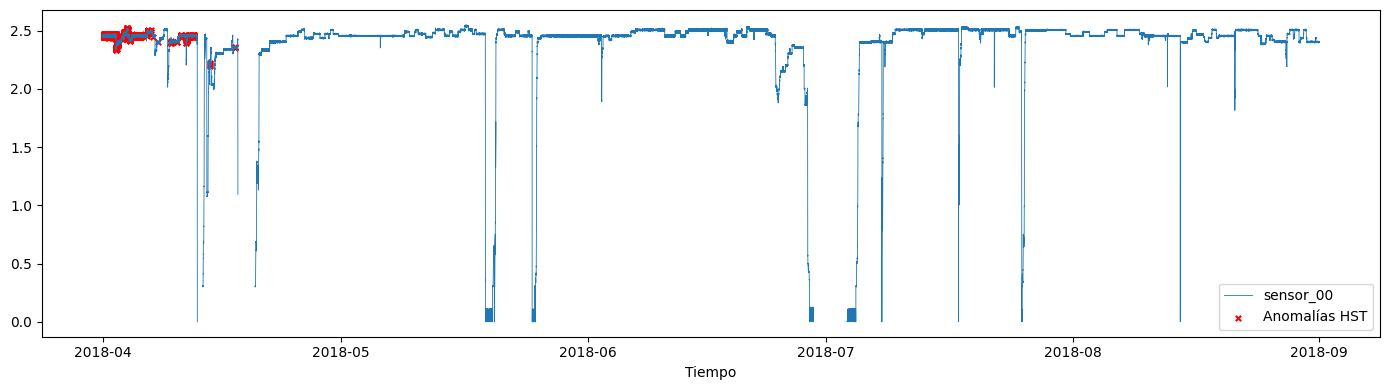

In [10]:
sensor = "sensor_00"  # puedes cambiar el sensor

plt.figure(figsize=(14, 4))
if "timestamp" in df.columns:
    x_axis = df["timestamp"]
    plt.xlabel("Tiempo")
else:
    x_axis = df.index
    plt.xlabel("Índice")

plt.plot(x_axis, df[sensor], label=sensor, linewidth=0.6)

mask = df["hst_anomaly_stream"]
plt.scatter(x_axis[mask], df.loc[mask, sensor],
            color="red", marker="x", label="Anomalías HST", s=15)

plt.legend()
plt.tight_layout()
plt.show()

## Conclusión
- El método **IQR** es muy sencillo e interpretable, pero solo analiza cada sensor por separado (no tiene en cuenta relaciones entre sensores).
- **K-Means offline** permite detectar puntos alejados de los centroides, capturando anomalías multivariantes, pero requiere volver a entrenar si llegan nuevos datos.
- **Half-Space Trees (HST)** en streaming trabaja de forma incremental, actualizando el modelo con cada nueva observación. Es más adecuado para un entorno tipo Industria 4.0 donde los sensores generan datos de forma continua.

En general, los métodos online basados en `river` son más realistas para mantenimiento predictivo, mientras que los métodos offline son útiles para análisis histórico y como línea base.